# 1. Import Libraries, Configuration Setup, and Load the Dataset

## 1.1 Install \& Import Libraries

In [1]:
# !pip install peft==0.13.2, transformers==4.41.1

In [2]:
# !pip install wordcloud

In [3]:
# !pip install imblearn

In [4]:
# !pip install lightgbm

In [5]:
# ── Standard library ─────────────────────────────────────
import os
import re
import gc
import json
import time
import random
import warnings
from pathlib import Path
from dataclasses import dataclass
from typing import Any, Dict, Tuple, Optional, List

# ── Core DS stack ────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# ── Scikit-learn ─────────────────────────────────────────
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix,
    f1_score, roc_curve, auc, accuracy_score,
)
from sklearn.utils import resample, shuffle
from sklearn.utils.class_weight import compute_class_weight

# ── PyTorch ──────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# ── Transformers ─────────────────────────────────────────
from transformers import (
    AutoTokenizer, AutoModel,
    AlbertModel, AlbertTokenizer,
    BertTokenizer,
)

# ── Notebook setup ───────────────────────────────────────
warnings.filterwarnings("ignore")


## 1.2 Seed \& Device

In [6]:
SEED = 2025

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


## 1.3 Configuration

In [7]:
DRIVE_PROJECT_PATH = "./06_AspectLabel"
RAW_DATA_FILE = "data/mental_health_unified_labels_final.csv"
OUTPUT_DIR = "outputs"

ALBERT_MODEL_NAME = "albert-base-v2"
BIOBERT_MODEL_NAME = "dmis-lab/biobert-v1.1"

TEXT_COLUMN = "statement"

# ── Aspect labels (3-class each: NONE / WEAK / CLEAR) ───
ASPECT_NAMES = [
    "u_depression_strength", "u_anxiety_strength", "u_suicidal_strength",
    "u_stress_strength", "u_bipolar_strength", "u_personality_disorder_strength",
]
ASPECT_CLASSES = ["NONE", "WEAK", "CLEAR"]   # ordinal: 0 < 1 < 2
NUM_ASPECT_CLASSES = len(ASPECT_CLASSES)
ASPECT_LABEL_MAP = {v: i for i, v in enumerate(ASPECT_CLASSES)}

# ── Training config ──────────────────────────────────────
MAX_TOKEN_LENGTH = 200
BATCH_SIZE = 128                   # A100: large batches to saturate GPU
N_ITERATIONS = 10
RANDOM_STATE = 42
PATIENCE = 3
NUM_WORKERS = 4                    # A100 systems have more CPU cores

# ── A100 optimizations ──────────────────────────────────
USE_BF16 = torch.cuda.is_available() and torch.cuda.get_device_capability()[0] >= 8
USE_COMPILE = hasattr(torch, "compile")  # PyTorch 2.0+
print(f"BF16: {USE_BF16} | torch.compile: {USE_COMPILE}")

# ── Loss weights (λ) — equal weighting across conditions ─
LOSS_WEIGHTS = {
    "u_depression_strength": 1.0,
    "u_anxiety_strength": 1.0,
    "u_suicidal_strength": 1.0,
    "u_stress_strength": 1.0,
    "u_bipolar_strength": 1.0,
    "u_personality_disorder_strength": 1.0,
}

# ── Retrain flag ─────────────────────────────────────────
RETRAIN = True

# ── Derived paths ────────────────────────────────────────
RAW_DATA_PATH = os.path.join(DRIVE_PROJECT_PATH, RAW_DATA_FILE)
OUTPUT_PATH = Path(DRIVE_PROJECT_PATH) / OUTPUT_DIR
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

MODEL_PATHS = {
    "albert": {
        "model":  OUTPUT_PATH / "best_albert_aspect.pth",
        "params": OUTPUT_PATH / "best_albert_aspect_params.json",
    },
    "biobert": {
        "model":  OUTPUT_PATH / "best_biobert_aspect.pth",
        "params": OUTPUT_PATH / "best_biobert_aspect_params.json",
    },
}

print("--- Aspect-Only Multi-Task Configuration (Mental Health) ---")
print(f"  Project    : {DRIVE_PROJECT_PATH}")
print(f"  Aspects    : {ASPECT_NAMES} × {NUM_ASPECT_CLASSES} classes")
print(f"  Classes    : {ASPECT_CLASSES}")
print(f"  Loss wts   : {LOSS_WEIGHTS}")
print(f"  Batch size : {BATCH_SIZE}")

BF16: True | torch.compile: True
--- Aspect-Only Multi-Task Configuration (Mental Health) ---
  Project    : ./06_AspectLabel
  Aspects    : ['u_depression_strength', 'u_anxiety_strength', 'u_suicidal_strength', 'u_stress_strength', 'u_bipolar_strength', 'u_personality_disorder_strength'] × 3 classes
  Classes    : ['NONE', 'WEAK', 'CLEAR']
  Loss wts   : {'u_depression_strength': 1.0, 'u_anxiety_strength': 1.0, 'u_suicidal_strength': 1.0, 'u_stress_strength': 1.0, 'u_bipolar_strength': 1.0, 'u_personality_disorder_strength': 1.0}
  Batch size : 128


## 1.4 Mount drive & Load the data

In [8]:
import os
if os.path.ismount("/content/drive"):
    # Already mounted, skip
    pass
else:
    !fusermount -u /content/drive 2>/dev/null
    !rm -rf /content/drive/*
    from google.colab import drive
    drive.mount("/content/drive/", force_remount=True)

df_raw = pd.read_csv(RAW_DATA_PATH, index_col=0)
print(f"Loaded {df_raw.shape[0]} rows.")

df_raw.head()

Mounted at /content/drive/
Loaded 53043 rows.


,statement,status,u_label,u_p_normal,u_p_depression,u_p_anxiety,u_p_suicidal,u_p_stress,u_p_bipolar,u_p_personality_disorder,...,u_model_version,u_system_fingerprint,u_annotation_timestamp,u_raw_json,u_n_conditions,u_any_clinical,u_normal_inferred,u_multilabel,u_max_clinical_prob,u_sum_clinical_prob
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
0,oh my gosh,Anxiety,NORMAL,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,gpt-4o-mini-2024-07-18,fp_373a14eb6f,2026-02-27T18:17:03.262768,"[\n {\n ""index"": 0,\n ""label"": ""NORMAL""...",0,False,True,NORMAL,0.0,0.0
1,"trouble sleeping, confused mind, restless hear...",Anxiety,ANXIETY,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,gpt-4o-mini-2024-07-18,fp_373a14eb6f,2026-02-27T18:17:03.262768,"[\n {\n ""index"": 0,\n ""label"": ""NORMAL""...",1,True,False,ANXIETY,1.0,1.0
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,ANXIETY,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,gpt-4o-mini-2024-07-18,fp_373a14eb6f,2026-02-27T18:17:03.262768,"[\n {\n ""index"": 0,\n ""label"": ""NORMAL""...",1,True,False,ANXIETY,1.0,1.0
3,I've shifted my focus to something else but I'...,Anxiety,ANXIETY,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,gpt-4o-mini-2024-07-18,fp_373a14eb6f,2026-02-27T18:17:03.262768,"[\n {\n ""index"": 0,\n ""label"": ""NORMAL""...",1,True,False,ANXIETY,1.0,1.0
4,"I'm restless and restless, it's been a month n...",Anxiety,ANXIETY,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,gpt-4o-mini-2024-07-18,fp_373a14eb6f,2026-02-27T18:17:03.262768,"[\n {\n ""index"": 0,\n ""label"": ""NORMAL""...",1,True,False,ANXIETY,1.0,1.0


In [9]:
# ── SCOPE GATE: keep only evaluable posts ────────────────
SPECIAL_LABELS = {"OUT_OF_SCOPE", "INSUFFICIENT"}
before = len(df_raw)
df_raw = df_raw[~df_raw["u_label"].isin(SPECIAL_LABELS)].reset_index(drop=True)
print(f"Scope gating: {before} → {len(df_raw)} rows "
      f"(removed {before - len(df_raw)} OUT_OF_SCOPE/INSUFFICIENT)")

df_raw.head()

Scope gating: 53043 → 53043 rows (removed 0 OUT_OF_SCOPE/INSUFFICIENT)


,statement,status,u_label,u_p_normal,u_p_depression,u_p_anxiety,u_p_suicidal,u_p_stress,u_p_bipolar,u_p_personality_disorder,...,u_model_version,u_system_fingerprint,u_annotation_timestamp,u_raw_json,u_n_conditions,u_any_clinical,u_normal_inferred,u_multilabel,u_max_clinical_prob,u_sum_clinical_prob
0,oh my gosh,Anxiety,NORMAL,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,gpt-4o-mini-2024-07-18,fp_373a14eb6f,2026-02-27T18:17:03.262768,"[\n {\n ""index"": 0,\n ""label"": ""NORMAL""...",0,False,True,NORMAL,0.0,0.0
1,"trouble sleeping, confused mind, restless hear...",Anxiety,ANXIETY,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,gpt-4o-mini-2024-07-18,fp_373a14eb6f,2026-02-27T18:17:03.262768,"[\n {\n ""index"": 0,\n ""label"": ""NORMAL""...",1,True,False,ANXIETY,1.0,1.0
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,ANXIETY,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,gpt-4o-mini-2024-07-18,fp_373a14eb6f,2026-02-27T18:17:03.262768,"[\n {\n ""index"": 0,\n ""label"": ""NORMAL""...",1,True,False,ANXIETY,1.0,1.0
3,I've shifted my focus to something else but I'...,Anxiety,ANXIETY,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,gpt-4o-mini-2024-07-18,fp_373a14eb6f,2026-02-27T18:17:03.262768,"[\n {\n ""index"": 0,\n ""label"": ""NORMAL""...",1,True,False,ANXIETY,1.0,1.0
4,"I'm restless and restless, it's been a month n...",Anxiety,ANXIETY,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,gpt-4o-mini-2024-07-18,fp_373a14eb6f,2026-02-27T18:17:03.262768,"[\n {\n ""index"": 0,\n ""label"": ""NORMAL""...",1,True,False,ANXIETY,1.0,1.0


In [10]:
df_raw = shuffle(df_raw, random_state=SEED).reset_index(drop=True)

# 2. Data Exploration \& Master Data Preparation

## 2.1 Master Data Preparation

### 2.1.1 Text cleaning

In [11]:
def clean_text(text: str) -> str:
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+", " urltoken ", text)
    text = re.sub(r"@\w+", " usertoken ", text)
    text = re.sub(r"#(\w+)", r" hashtag_\1 ", text)
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


print("Cleaning text...")
df_clean = df_raw.copy()
df_clean[TEXT_COLUMN] = df_clean[TEXT_COLUMN].apply(clean_text)

Cleaning text...


### 2.1.2 Validate & encode aspect labels

In [12]:
print("\nCondition strength label distributions:")
for asp in ASPECT_NAMES:
    if asp not in df_clean.columns:
        raise ValueError(f"Missing column: {asp}")

    # Coerce to uppercase string for consistent matching
    df_clean[asp] = df_clean[asp].astype(str).str.upper().str.strip()

    # Validate against ASPECT_CLASSES (NONE / WEAK / CLEAR)
    valid_mask = df_clean[asp].isin(ASPECT_CLASSES)
    n_invalid = (~valid_mask).sum()
    if n_invalid > 0:
        print(f"  WARNING: {asp} has {n_invalid} invalid values — setting to NONE")
        df_clean.loc[~valid_mask, asp] = "NONE"

    # Encode to integer using ASPECT_LABEL_MAP
    df_clean[f"{asp}_idx"] = df_clean[asp].map(ASPECT_LABEL_MAP)
    print(f"  {asp}: {df_clean[asp].value_counts().to_dict()}")


Condition strength label distributions:
  u_depression_strength: {'NONE': 32447, 'CLEAR': 17870, 'WEAK': 2726}
  u_anxiety_strength: {'NONE': 41826, 'CLEAR': 9439, 'WEAK': 1778}
  u_suicidal_strength: {'NONE': 39832, 'CLEAR': 12311, 'WEAK': 900}
  u_stress_strength: {'NONE': 42864, 'WEAK': 5887, 'CLEAR': 4292}
  u_bipolar_strength: {'NONE': 51190, 'CLEAR': 1405, 'WEAK': 448}
  u_personality_disorder_strength: {'NONE': 51798, 'WEAK': 684, 'CLEAR': 561}


## 2.3 Master Data Split

In [13]:
# Use first condition as stratification proxy
y_for_split = df_clean[f"{ASPECT_NAMES[0]}_idx"]
groups = df_clean[TEXT_COLUMN]

# 80/20 → train+val / test
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
trainval_idx, test_idx = next(gss_test.split(df_clean, y_for_split, groups=groups))

split = np.full(len(df_clean), "train", dtype=object)
split[test_idx] = "test"

# train → train + val (75/25 of 80% = 60/20)
df_trainval = df_clean.iloc[trainval_idx].copy().reset_index(drop=True)
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
train_idx2, val_idx = next(
    gss_val.split(df_trainval, df_trainval[f"{ASPECT_NAMES[0]}_idx"],
                  groups=df_trainval[TEXT_COLUMN])
)
split[trainval_idx[val_idx]] = "val"
df_clean["split"] = split

print("\nSplit counts:")
print(df_clean["split"].value_counts())

# Leakage check
group_split_nunique = df_clean.groupby(TEXT_COLUMN)["split"].nunique()
n_leaky = (group_split_nunique > 1).sum()
assert n_leaky == 0, f"{n_leaky} text groups leak across splits!"
print("Leakage check passed.")

# Save
split_path = OUTPUT_PATH / "master_split_multitarget.csv"
df_clean.to_csv(split_path, index=False)
print(f"Saved → {split_path}")


Split counts:
split
train    31976
test     10550
val      10517
Name: count, dtype: int64
Leakage check passed.
Saved → ./06_AspectLabel/outputs/master_split_multitarget.csv


# 3. ALBERT \& BioBERT Models (Multi-aspect)

## 3.1 Shared helper functions

In [14]:
def bootstrap_f1_ci(y_true, y_pred, n_iterations=1000, average="weighted"):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    scores = []
    for _ in range(n_iterations):
        idx = resample(np.arange(len(y_true)))
        try:
            scores.append(f1_score(y_true[idx], y_pred[idx], average=average))
        except ValueError:
            continue
    if not scores:
        return np.nan, np.nan, np.nan
    return np.mean(scores), np.percentile(scores, 2.5), np.percentile(scores, 97.5)


def bootstrap_auc_ci(y_true, y_scores, n_iterations=1000, average="macro"):
    y_true, y_scores = np.asarray(y_true), np.asarray(y_scores)
    scores = []
    for _ in range(n_iterations):
        idx = resample(np.arange(len(y_true)))
        try:
            scores.append(
                roc_auc_score(y_true[idx], y_scores[idx],
                              average=average, multi_class="ovr")
            )
        except ValueError:
            continue
    if not scores:
        return np.nan, np.nan, np.nan
    return np.mean(scores), np.percentile(scores, 2.5), np.percentile(scores, 97.5)


def plot_confusion_matrix(y_true, y_pred, class_names, title="Model", save_dir=None):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix — {title}")
    plt.tight_layout()
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        path = os.path.join(save_dir, f"{title}_confusion_matrix.png")
        plt.savefig(path, dpi=300)
        print(f"Saved → {path}")
    plt.show()


## 3.2 Data splits \& labels

In [15]:
df_train = df_clean[df_clean["split"] == "train"].copy()
df_val   = df_clean[df_clean["split"] == "val"].copy()
df_test  = df_clean[df_clean["split"] == "test"].copy()

train_texts = df_train[TEXT_COLUMN].astype(str).tolist()
val_texts   = df_val[TEXT_COLUMN].astype(str).tolist()
test_texts  = df_test[TEXT_COLUMN].astype(str).tolist()

# Aspect labels (hard, 3-class each: NONE / WEAK / CLEAR)
y_train_aspects = {asp: df_train[f"{asp}_idx"].to_numpy(dtype=np.int64) for asp in ASPECT_NAMES}
y_val_aspects   = {asp: df_val[f"{asp}_idx"].to_numpy(dtype=np.int64) for asp in ASPECT_NAMES}
y_test_aspects  = {asp: df_test[f"{asp}_idx"].to_numpy(dtype=np.int64) for asp in ASPECT_NAMES}

print(f"Train: {len(train_texts)} | Val: {len(val_texts)} | Test: {len(test_texts)}")
for asp in ASPECT_NAMES:
    print(f"{asp}: {np.bincount(y_train_aspects[asp], minlength=NUM_ASPECT_CLASSES)}")

Train: 31976 | Val: 10517 | Test: 10550
u_depression_strength: [19561  1694 10721]
u_anxiety_strength: [25215  1085  5676]
u_suicidal_strength: [24105   527  7344]
u_stress_strength: [25837  3582  2557]
u_bipolar_strength: [30849   270   857]
u_personality_disorder_strength: [31271   381   324]


## 3.3 Generic multi-task model componets

In [16]:
# ── Pre-tokenization ─────────────────────────────────────
def batch_tokenize(texts, tokenizer, max_len):
    enc = tokenizer(
        [str(t) for t in texts],
        truncation=True, padding="max_length",
        max_length=max_len, return_tensors="pt",
    )
    return enc["input_ids"], enc["attention_mask"]


# ── Aspect-Only Dataset ─────────────────────────────────
class AspectDataset(Dataset):
    """Pre-tokenized dataset with aspect labels only."""

    def __init__(self, input_ids, attention_masks, aspect_labels_dict):
        self.input_ids = input_ids
        self.attention_masks = attention_masks
        self.aspect_labels = {
            asp: np.asarray(labels, dtype=np.int64)
            for asp, labels in aspect_labels_dict.items()
        }

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        item = {
            "input_ids": self.input_ids[idx],
            "attention_mask": self.attention_masks[idx],
        }
        for asp in ASPECT_NAMES:
            item[f"{asp}_label"] = torch.tensor(
                self.aspect_labels[asp][idx], dtype=torch.long
            )
        return item


# ── Helper: short display name for an aspect column ─────
def asp_display(asp):
    """u_depression_strength → depression"""
    return asp.replace("u_", "").replace("_strength", "")


# ── Aspect-Only Classifier ──────────────────────────────
class AspectTransformer(nn.Module):
    """Shared transformer backbone with 6 aspect heads (3-class each).
    Each head predicts NONE / WEAK / CLEAR for one condition."""

    def __init__(self, base_model, hidden_size,
                 num_aspect_classes=NUM_ASPECT_CLASSES,
                 dropout=0.1):
        super().__init__()
        self.base = base_model
        self.dropout = nn.Dropout(dropout)
        self.aspect_heads = nn.ModuleDict({
            asp: nn.Linear(hidden_size, num_aspect_classes)
            for asp in ASPECT_NAMES
        })

    def forward(self, input_ids, attention_mask):
        out = self.base(input_ids=input_ids, attention_mask=attention_mask)
        cls = self.dropout(out.last_hidden_state[:, 0, :])
        return {asp: head(cls) for asp, head in self.aspect_heads.items()}


# ── Class weights for each task ──────────────────────────
def compute_task_weights(labels, num_classes, device=DEVICE):
    """Compute balanced class weights for a single task."""
    unique = np.unique(labels)
    cw = compute_class_weight("balanced", classes=unique, y=labels)
    full_cw = np.ones(num_classes, dtype=np.float32)
    for cls_id, w in zip(unique, cw):
        full_cw[cls_id] = w
    return torch.tensor(full_cw, dtype=torch.float32).to(device)


def train_aspect_model(model, train_loader, val_loader,
                       aspect_weights_dict,
                       lr=2e-5, max_epochs=8, patience=PATIENCE):
    """Aspect-only multi-task training with equal weights.
    BF16 autocast for A100. Best epoch by mean aspect weighted F1."""
    model.to(DEVICE)

    # torch.compile for A100 (PyTorch 2.0+)
    if USE_COMPILE:
        model = torch.compile(model)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    # CE losses with class weights
    aspect_criteria = {
        asp: nn.CrossEntropyLoss(weight=aspect_weights_dict[asp])
        for asp in ASPECT_NAMES
    }

    best_f1, best_state, best_epoch = -1.0, None, -1
    no_improve = 0

    for epoch in range(1, max_epochs + 1):
        # ── Train ────────────────────────────────────────
        model.train()
        epoch_losses = []
        for batch in train_loader:
            ids  = batch["input_ids"].to(DEVICE, non_blocking=True)
            mask = batch["attention_mask"].to(DEVICE, non_blocking=True)

            optimizer.zero_grad()

            # BF16 autocast for A100
            with torch.autocast("cuda", dtype=torch.bfloat16, enabled=USE_BF16):
                aspect_logits = model(ids, mask)

                loss = torch.tensor(0.0, device=DEVICE)
                for asp in ASPECT_NAMES:
                    asp_y = batch[f"{asp}_label"].to(DEVICE, non_blocking=True)
                    loss = loss + LOSS_WEIGHTS[asp] * aspect_criteria[asp](
                        aspect_logits[asp], asp_y
                    )

            loss.backward()
            optimizer.step()
            epoch_losses.append(loss.item())

        train_loss = float(np.mean(epoch_losses))

        # ── Validate ─────────────────────────────────────
        model.eval()
        val_asp_preds = {asp: [] for asp in ASPECT_NAMES}
        val_asp_true  = {asp: [] for asp in ASPECT_NAMES}

        with torch.no_grad():
            for batch in val_loader:
                ids  = batch["input_ids"].to(DEVICE, non_blocking=True)
                mask = batch["attention_mask"].to(DEVICE, non_blocking=True)

                with torch.autocast("cuda", dtype=torch.bfloat16, enabled=USE_BF16):
                    aspect_logits = model(ids, mask)

                for asp in ASPECT_NAMES:
                    val_asp_preds[asp].extend(
                        aspect_logits[asp].float().argmax(dim=1).cpu().numpy()
                    )
                    val_asp_true[asp].extend(batch[f"{asp}_label"].numpy())

        # Mean aspect weighted F1 as selection criterion
        asp_f1s = {}
        for asp in ASPECT_NAMES:
            asp_f1s[asp] = f1_score(val_asp_true[asp], val_asp_preds[asp],
                                    average="weighted")
        mean_f1 = np.mean(list(asp_f1s.values()))

        asp_str = " | ".join(f"{asp_display(a)}={v:.3f}" for a, v in asp_f1s.items())
        print(f"  Epoch {epoch}/{max_epochs} | Loss={train_loss:.4f} | "
              f"MeanF1={mean_f1:.4f} | {asp_str}")

        # Best by mean aspect F1
        # Handle compiled model: extract _orig_mod if compiled
        raw = model._orig_mod if hasattr(model, "_orig_mod") else model
        if mean_f1 > best_f1:
            best_f1 = mean_f1
            best_state = {k: v.cpu().clone() for k, v in raw.state_dict().items()}
            best_epoch = epoch
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  Early stopping at epoch {epoch}.")
                break

    if best_state:
        raw = model._orig_mod if hasattr(model, "_orig_mod") else model
        raw.load_state_dict(best_state)
    return best_f1, raw, best_epoch


# =========================================================
# EVALUATION
# =========================================================
def evaluate_aspects(model, test_loader, model_name, save_dir=None):
    """Evaluate all aspect heads with bootstrap CIs."""
    model.eval()
    all_asp_logits = {asp: [] for asp in ASPECT_NAMES}
    all_asp_true   = {asp: [] for asp in ASPECT_NAMES}

    with torch.no_grad():
        for batch in test_loader:
            ids  = batch["input_ids"].to(DEVICE, non_blocking=True)
            mask = batch["attention_mask"].to(DEVICE, non_blocking=True)

            with torch.autocast("cuda", dtype=torch.bfloat16, enabled=USE_BF16):
                aspect_logits = model(ids, mask)

            for asp in ASPECT_NAMES:
                all_asp_logits[asp].append(aspect_logits[asp].float().cpu().numpy())
                all_asp_true[asp].extend(batch[f"{asp}_label"].numpy())

    results = {}
    for asp in ASPECT_NAMES:
        asp_logits_np = np.concatenate(all_asp_logits[asp])
        asp_probs = torch.softmax(torch.tensor(asp_logits_np), dim=1).numpy()
        asp_preds = asp_probs.argmax(axis=1)
        asp_true = np.asarray(all_asp_true[asp])

        short = asp_display(asp)
        print(f"\n{'='*60}")
        print(f"{model_name} — {short.upper()} (3-class: NONE/WEAK/CLEAR)")
        print(f"{'='*60}")
        print(classification_report(
            asp_true, asp_preds,
            labels=list(range(NUM_ASPECT_CLASSES)),
            target_names=ASPECT_CLASSES, digits=4, zero_division=0,
        ))

        f1_m, f1_lo, f1_hi = bootstrap_f1_ci(asp_true, asp_preds)
        print(f"Weighted F1: {f1_m:.4f}  95% CI [{f1_lo:.4f}, {f1_hi:.4f}]")

        plot_confusion_matrix(asp_true, asp_preds, ASPECT_CLASSES,
                              title=f"{model_name}_Aspect_{short}",
                              save_dir=save_dir)

        results[asp] = {
            "y_true": asp_true, "y_pred": asp_preds, "y_prob": asp_probs,
            "f1_weighted": f1_m, "f1_ci": (f1_lo, f1_hi),
        }

    return results


def build_loaders(tokenizer, model_label):
    """Tokenize and build train/val/test loaders."""
    print(f"\nTokenizing for {model_label}...")
    train_ids, train_masks = batch_tokenize(train_texts, tokenizer, MAX_TOKEN_LENGTH)
    val_ids, val_masks     = batch_tokenize(val_texts, tokenizer, MAX_TOKEN_LENGTH)
    test_ids, test_masks   = batch_tokenize(test_texts, tokenizer, MAX_TOKEN_LENGTH)

    loader_kw = dict(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS,
                     pin_memory=True, persistent_workers=True)

    train_loader = DataLoader(
        AspectDataset(train_ids, train_masks, y_train_aspects),
        shuffle=True, **loader_kw)
    val_loader = DataLoader(
        AspectDataset(val_ids, val_masks, y_val_aspects),
        shuffle=False, **loader_kw)
    test_loader = DataLoader(
        AspectDataset(test_ids, test_masks, y_test_aspects),
        shuffle=False, **loader_kw)

    return train_loader, val_loader, test_loader


# ── Compute class weights ────────────────────────────────
aspect_weights = {
    asp: compute_task_weights(y_train_aspects[asp], NUM_ASPECT_CLASSES)
    for asp in ASPECT_NAMES
}
for asp in ASPECT_NAMES:
    print(f"{asp_display(asp)} class weights: {aspect_weights[asp].cpu().numpy().round(3)}")

depression class weights: [0.545 6.292 0.994]
anxiety class weights: [0.423 9.824 1.878]
suicidal class weights: [ 0.442 20.225  1.451]
stress class weights: [0.413 2.976 4.168]
bipolar class weights: [ 0.346 39.477 12.437]
personality_disorder class weights: [ 0.341 27.976 32.897]


## 3.4 ALBERT: Soft-label training

In [17]:
print("\n" + "=" * 60)
print("ALBERT — Multi-Task Training")
print("=" * 60)


ALBERT — Multi-Task Training


### 3.4.1 Pre-tokenize

In [18]:
albert_tokenizer = AlbertTokenizer.from_pretrained(ALBERT_MODEL_NAME)
train_loader_albert, val_loader_albert, test_loader_albert = \
    build_loaders(albert_tokenizer, "ALBERT")

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/760k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.31M [00:00<?, ?B/s]


Tokenizing for ALBERT...


### 3.4.2 Hyperparameter tuning

In [19]:
if RETRAIN:
    set_seed()
    start = time.time()

    param_space = {
        "lr":      (np.log10(1e-5), np.log10(3e-5)),
        "epochs":  (6, 10),
        "dropout": (0.0, 0.25),
    }

    best_f1_albert, best_params_albert, best_albert = 0, None, None

    for i in tqdm(range(N_ITERATIONS), desc="ALBERT Aspect Search"):
        hp = {
            "lr":      float(10 ** np.random.uniform(*param_space["lr"])),
            "epochs":  int(np.random.randint(*param_space["epochs"])),
            "dropout": float(np.random.uniform(*param_space["dropout"])),
        }

        base = AlbertModel.from_pretrained(ALBERT_MODEL_NAME)
        model = AspectTransformer(
            base, base.config.hidden_size, dropout=hp["dropout"],
        )

        f1_val, model, best_ep = train_aspect_model(
            model, train_loader_albert, val_loader_albert,
            aspect_weights,
            lr=hp["lr"], max_epochs=hp["epochs"],
        )

        if f1_val > best_f1_albert:
            best_f1_albert = f1_val
            best_params_albert = hp
            best_albert = model
            torch.save(model.state_dict(), MODEL_PATHS["albert"]["model"])

        gc.collect()
        torch.cuda.empty_cache()

    print(f"ALBERT tuning: {time.time()-start:.1f}s | Best F1={best_f1_albert:.4f}")
    print(f"Best params: {best_params_albert}")

    with open(MODEL_PATHS["albert"]["params"], "w") as f:
        json.dump(best_params_albert, f, indent=2)

else:
    with open(MODEL_PATHS["albert"]["params"]) as f:
        best_params_albert = json.load(f)
    base = AlbertModel.from_pretrained(ALBERT_MODEL_NAME)
    best_albert = AspectTransformer(
        base, base.config.hidden_size,
        dropout=best_params_albert.get("dropout", 0.1),
    )
    best_albert.load_state_dict(
        torch.load(MODEL_PATHS["albert"]["model"], map_location=DEVICE)
    )

best_albert.to(DEVICE)
best_albert.eval()

ALBERT Aspect Search:   0%|          | 0/10 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/684 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/47.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

AlbertModel LOAD REPORT from: albert-base-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
predictions.dense.bias       | UNEXPECTED |  | 
predictions.bias             | UNEXPECTED |  | 
predictions.dense.weight     | UNEXPECTED |  | 
predictions.decoder.bias     | UNEXPECTED |  | 
predictions.LayerNorm.bias   | UNEXPECTED |  | 
predictions.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

AlbertModel LOAD REPORT from: albert-base-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
predictions.dense.bias       | UNEXPECTED |  | 
predictions.bias             | UNEXPECTED |  | 
predictions.dense.weight     | UNEXPECTED |  | 
predictions.decoder.bias     | UNEXPECTED |  | 
predictions.LayerNorm.bias   | UNEXPECTED |  | 
predictions.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Epoch 1/9 | Loss=5.4288 | MeanF1=0.7789 | depression=0.765 | anxiety=0.805 | suicidal=0.744 | stress=0.653 | bipolar=0.902 | personality_disorder=0.804
  Epoch 2/9 | Loss=4.3829 | MeanF1=0.8085 | depression=0.756 | anxiety=0.800 | suicidal=0.829 | stress=0.645 | bipolar=0.946 | personality_disorder=0.875
  Epoch 3/9 | Loss=3.8886 | MeanF1=0.8200 | depression=0.793 | anxiety=0.806 | suicidal=0.838 | stress=0.668 | bipolar=0.934 | personality_disorder=0.880
  Epoch 4/9 | Loss=3.5041 | MeanF1=0.8316 | depression=0.775 | anxiety=0.821 | suicidal=0.848 | stress=0.667 | bipolar=0.945 | personality_disorder=0.934
  Epoch 5/9 | Loss=3.1099 | MeanF1=0.8321 | depression=0.799 | anxiety=0.801 | suicidal=0.862 | stress=0.655 | bipolar=0.963 | personality_disorder=0.913
  Epoch 6/9 | Loss=2.7570 | MeanF1=0.8211 | depression=0.786 | anxiety=0.799 | suicidal=0.866 | stress=0.648 | bipolar=0.952 | personality_disorder=0.876
  Epoch 7/9 | Loss=2.3085 | MeanF1=0.8570 | depression=0.811 | anxiety=0.838

ALBERT Aspect Search: 100%|██████████| 10/10 [56:56<00:00, 341.69s/it]

ALBERT tuning: 3416.9s | Best F1=0.8617
Best params: {'lr': 1.0897647295667571e-05, 'epochs': 9, 'dropout': 0.06214965916767748}


AspectTransformer(
  (base): AlbertModel(
    (embeddings): AlbertEmbeddings(
      (word_embeddings): Embedding(30000, 128, padding_idx=0)
      (position_embeddings): Embedding(512, 128)
      (token_type_embeddings): Embedding(2, 128)
      (LayerNorm): LayerNorm((128,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0, inplace=False)
    )
    (encoder): AlbertTransformer(
      (embedding_hidden_mapping_in): Linear(in_features=128, out_features=768, bias=True)
      (albert_layer_groups): ModuleList(
        (0): AlbertLayerGroup(
          (albert_layers): ModuleList(
            (0): AlbertLayer(
              (full_layer_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
              (attention): AlbertAttention(
                (attention_dropout): Dropout(p=0, inplace=False)
                (output_dropout): Dropout(p=0, inplace=False)
                (query): Linear(in_features=768, out_features=768, bias=True)
                (key): Linear(i

### 3.4.3 Model evaluation


ALBERT — DEPRESSION (3-class: NONE/WEAK/CLEAR)
              precision    recall  f1-score   support

        NONE     0.9432    0.7903    0.8600      6447
        WEAK     0.1608    0.3813    0.2262       535
       CLEAR     0.7456    0.8105    0.7767      3568

    accuracy                         0.7764     10550
   macro avg     0.6165    0.6607    0.6209     10550
weighted avg     0.8367    0.7764    0.7997     10550

Weighted F1: 0.7997  95% CI [0.7923, 0.8070]
Saved → ./06_AspectLabel/outputs/ALBERT_Aspect_depression_confusion_matrix.png


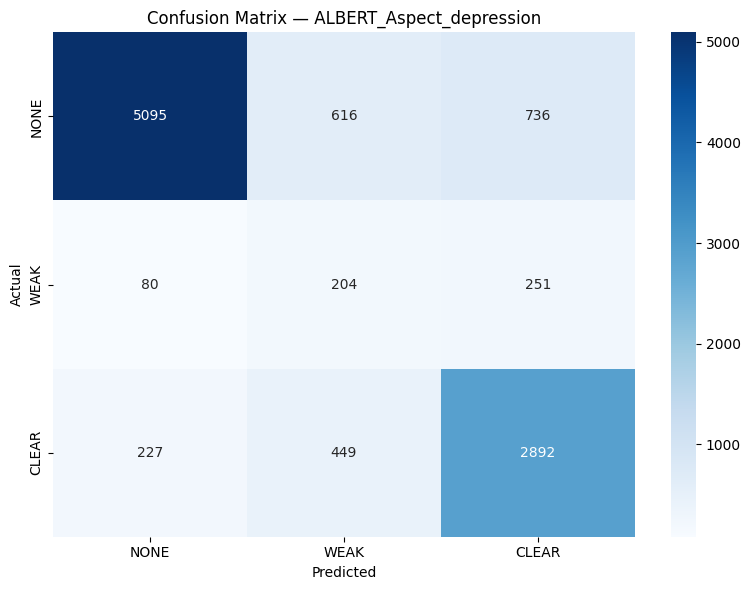


ALBERT — ANXIETY (3-class: NONE/WEAK/CLEAR)
              precision    recall  f1-score   support

        NONE     0.9490    0.8660    0.9056      8314
        WEAK     0.1132    0.2934    0.1634       351
       CLEAR     0.6732    0.7332    0.7019      1885

    accuracy                         0.8232     10550
   macro avg     0.5784    0.6309    0.5903     10550
weighted avg     0.8719    0.8232    0.8445     10550

Weighted F1: 0.8445  95% CI [0.8381, 0.8516]
Saved → ./06_AspectLabel/outputs/ALBERT_Aspect_anxiety_confusion_matrix.png


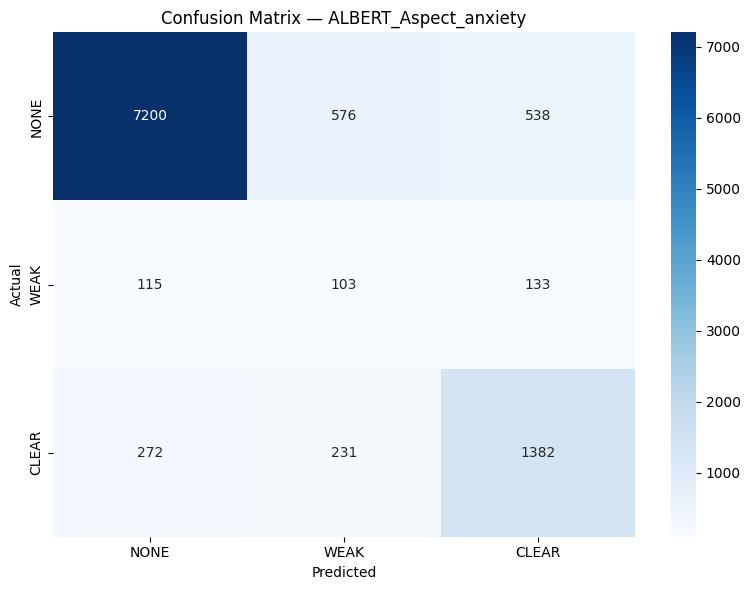


ALBERT — SUICIDAL (3-class: NONE/WEAK/CLEAR)
              precision    recall  f1-score   support

        NONE     0.9594    0.8741    0.9147      7887
        WEAK     0.0970    0.2736    0.1432       201
       CLEAR     0.7508    0.8530    0.7986      2462

    accuracy                         0.8577     10550
   macro avg     0.6024    0.6669    0.6189     10550
weighted avg     0.8943    0.8577    0.8730     10550

Weighted F1: 0.8729  95% CI [0.8671, 0.8794]
Saved → ./06_AspectLabel/outputs/ALBERT_Aspect_suicidal_confusion_matrix.png


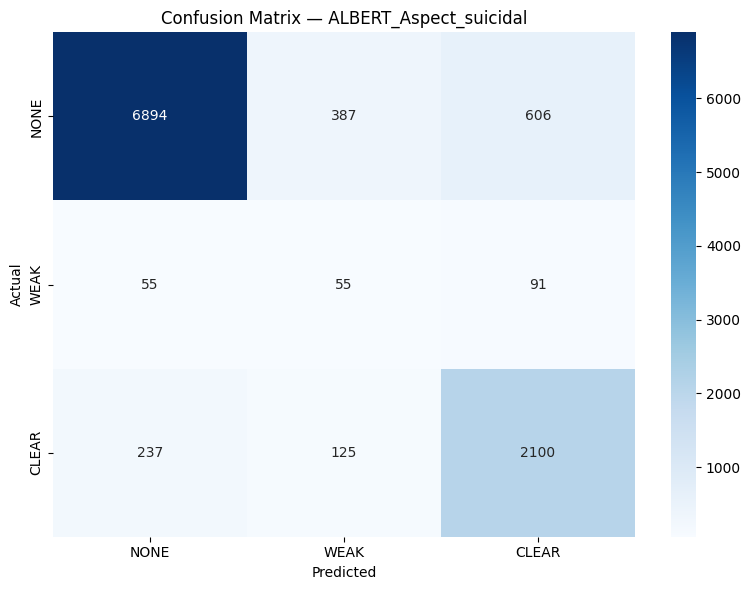


ALBERT — STRESS (3-class: NONE/WEAK/CLEAR)
              precision    recall  f1-score   support

        NONE     0.9194    0.6942    0.7911      8531
        WEAK     0.2087    0.4743    0.2898      1189
       CLEAR     0.3492    0.5916    0.4392       830

    accuracy                         0.6613     10550
   macro avg     0.4924    0.5867    0.5067     10550
weighted avg     0.7945    0.6613    0.7069     10550

Weighted F1: 0.7070  95% CI [0.6995, 0.7147]
Saved → ./06_AspectLabel/outputs/ALBERT_Aspect_stress_confusion_matrix.png


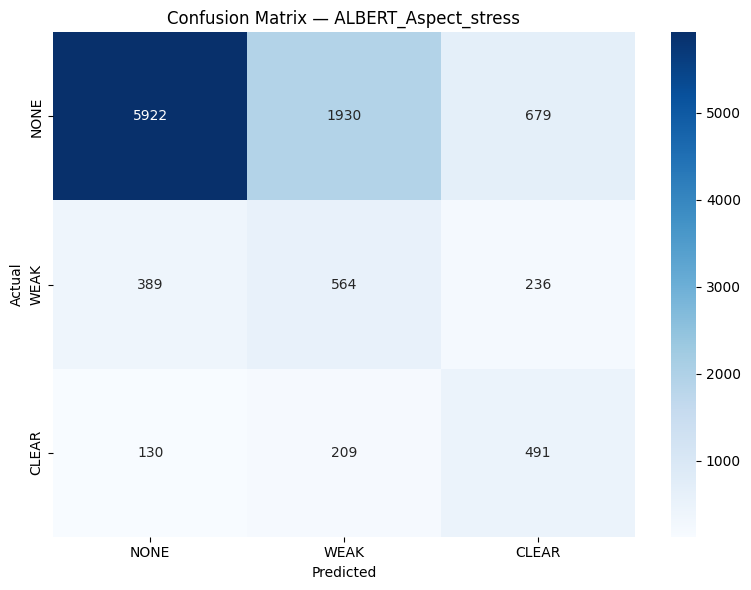


ALBERT — BIPOLAR (3-class: NONE/WEAK/CLEAR)
              precision    recall  f1-score   support

        NONE     0.9950    0.9774    0.9861     10196
        WEAK     0.1000    0.1750    0.1273        80
       CLEAR     0.6091    0.8759    0.7186       274

    accuracy                         0.9687     10550
   macro avg     0.5680    0.6761    0.6107     10550
weighted avg     0.9782    0.9687    0.9727     10550

Weighted F1: 0.9728  95% CI [0.9698, 0.9756]
Saved → ./06_AspectLabel/outputs/ALBERT_Aspect_bipolar_confusion_matrix.png


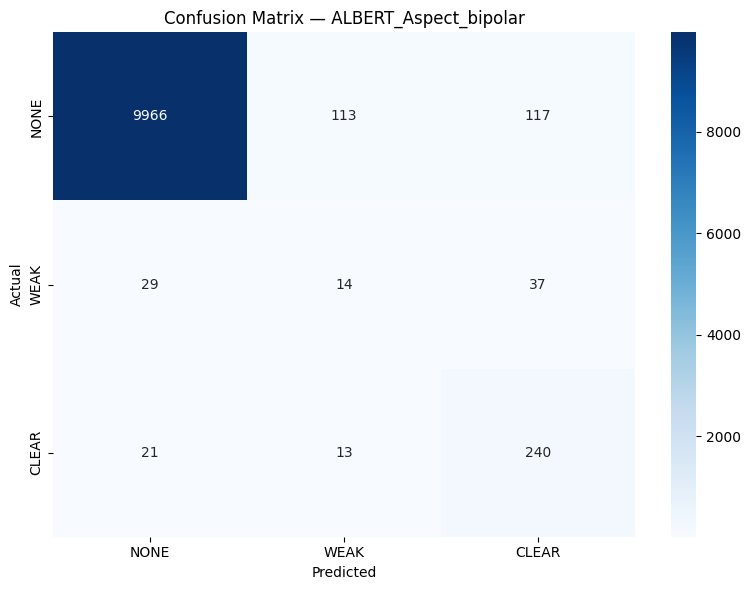


ALBERT — PERSONALITY_DISORDER (3-class: NONE/WEAK/CLEAR)
              precision    recall  f1-score   support

        NONE     0.9873    0.9663    0.9767     10276
        WEAK     0.1183    0.1987    0.1483       156
       CLEAR     0.2739    0.5339    0.3621       118

    accuracy                         0.9501     10550
   macro avg     0.4598    0.5663    0.4957     10550
weighted avg     0.9664    0.9501    0.9576     10550

Weighted F1: 0.9575  95% CI [0.9539, 0.9611]
Saved → ./06_AspectLabel/outputs/ALBERT_Aspect_personality_disorder_confusion_matrix.png


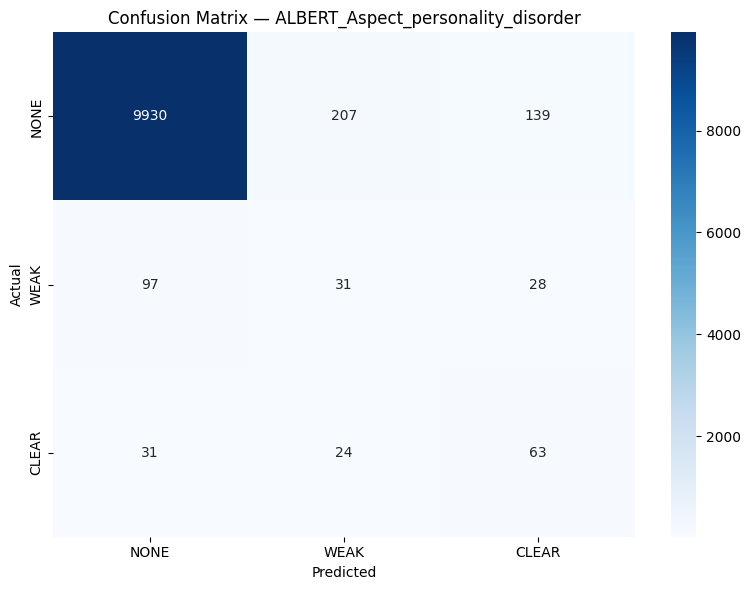

In [20]:
albert_results = evaluate_aspects(
    best_albert, test_loader_albert, "ALBERT", save_dir=str(OUTPUT_PATH)
)

## 3.5 BioBERT: Soft-label training

In [21]:
print("\n" + "=" * 60)
print("BioBERT — Multi-Task Training")
print("=" * 60)


BioBERT — Multi-Task Training


### 3.5.1 Pre-tokenize

In [22]:
biobert_tokenizer = BertTokenizer.from_pretrained(BIOBERT_MODEL_NAME)
train_loader_biobert, val_loader_biobert, test_loader_biobert = \
    build_loaders(biobert_tokenizer, "BioBERT")

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]


Tokenizing for BioBERT...


### 3.5.2 Hyperparameter tuning

In [23]:
if RETRAIN:
    set_seed()
    start = time.time()

    best_f1_biobert, best_params_biobert, best_biobert = 0, None, None

    for i in tqdm(range(N_ITERATIONS), desc="BioBERT Aspect Search"):
        hp = {
            "lr":      float(10 ** np.random.uniform(*param_space["lr"])),
            "epochs":  int(np.random.randint(*param_space["epochs"])),
            "dropout": float(np.random.uniform(*param_space["dropout"])),
        }

        base = AutoModel.from_pretrained(BIOBERT_MODEL_NAME)
        model = AspectTransformer(
            base, base.config.hidden_size, dropout=hp["dropout"],
        )

        f1_val, model, best_ep = train_aspect_model(
            model, train_loader_biobert, val_loader_biobert,
            aspect_weights,
            lr=hp["lr"], max_epochs=hp["epochs"],
        )

        if f1_val > best_f1_biobert:
            best_f1_biobert = f1_val
            best_params_biobert = hp
            best_biobert = model
            torch.save(model.state_dict(), MODEL_PATHS["biobert"]["model"])

        gc.collect()
        torch.cuda.empty_cache()

    print(f"BioBERT tuning: {time.time()-start:.1f}s | Best F1={best_f1_biobert:.4f}")
    print(f"Best params: {best_params_biobert}")

    with open(MODEL_PATHS["biobert"]["params"], "w") as f:
        json.dump(best_params_biobert, f, indent=2)

else:
    with open(MODEL_PATHS["biobert"]["params"]) as f:
        best_params_biobert = json.load(f)
    base = AutoModel.from_pretrained(BIOBERT_MODEL_NAME)
    best_biobert = AspectTransformer(
        base, base.config.hidden_size,
        dropout=best_params_biobert.get("dropout", 0.1),
    )
    best_biobert.load_state_dict(
        torch.load(MODEL_PATHS["biobert"]["model"], map_location=DEVICE)
    )

best_biobert.to(DEVICE)
best_biobert.eval()

BioBERT Aspect Search:   0%|          | 0/10 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/462 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/433M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  Epoch 1/9 | Loss=5.2134 | MeanF1=0.8272 | depression=0.785 | anxiety=0.811 | suicidal=0.834 | stress=0.730 | bipolar=0.957 | personality_disorder=0.845
  Epoch 2/9 | Loss=4.1789 | MeanF1=0.8284 | depression=0.771 | anxiety=0.804 | suicidal=0.835 | stress=0.681 | bipolar=0.959 | personality_disorder=0.922
  Epoch 3/9 | Loss=3.6666 | MeanF1=0.8251 | depression=0.795 | anxiety=0.823 | suicidal=0.846 | stress=0.643 | bipolar=0.953 | personality_disorder=0.891
  Epoch 4/9 | Loss=3.1822 | MeanF1=0.8285 | depression=0.741 | anxiety=0.815 | suicidal=0.862 | stress=0.670 | bipolar=0.959 | personality_disorder=0.924
  Epoch 5/9 | Loss=2.7461 | MeanF1=0.8325 | depression=0.782 | anxiety=0.829 | suicidal=0.841 | stress=0.706 | bipolar=0.947 | personality_disorder=0.890
  Epoch 6/9 | Loss=2.3286 | MeanF1=0.8395 | depression=0.785 | anxiety=0.800 | suicidal=0.858 | stress=0.713 | bipolar=0.963 | personality_disorder=0.918
  Epoch 7/9 | Loss=2.0163 | MeanF1=0.8437 | depression=0.784 | anxiety=0.825

BioBERT Aspect Search: 100%|██████████| 10/10 [35:53<00:00, 215.35s/it]


BioBERT tuning: 2153.5s | Best F1=0.8640
Best params: {'lr': 2.9768448441450054e-05, 'epochs': 9, 'dropout': 0.22900784668310975}


AspectTransformer(
  (base): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(28996, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise

### 3.5.3 Model Evaluation


BioBERT — DEPRESSION (3-class: NONE/WEAK/CLEAR)
              precision    recall  f1-score   support

        NONE     0.9375    0.8077    0.8678      6447
        WEAK     0.1595    0.4935    0.2411       535
       CLEAR     0.7740    0.7248    0.7486      3568

    accuracy                         0.7637     10550
   macro avg     0.6237    0.6753    0.6191     10550
weighted avg     0.8428    0.7637    0.7957     10550

Weighted F1: 0.7955  95% CI [0.7885, 0.8025]
Saved → ./06_AspectLabel/outputs/BioBERT_Aspect_depression_confusion_matrix.png


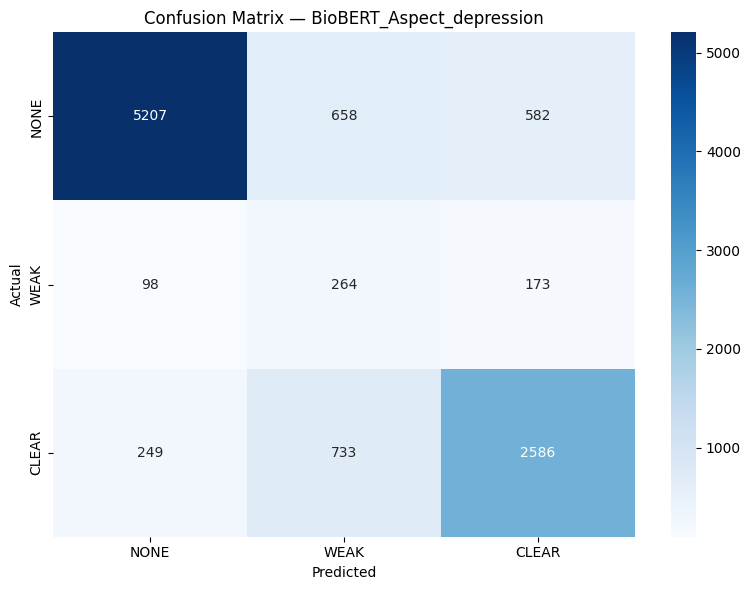


BioBERT — ANXIETY (3-class: NONE/WEAK/CLEAR)
              precision    recall  f1-score   support

        NONE     0.9514    0.8810    0.9149      8314
        WEAK     0.1360    0.3048    0.1880       351
       CLEAR     0.6875    0.7528    0.7187      1885

    accuracy                         0.8390     10550
   macro avg     0.5916    0.6462    0.6072     10550
weighted avg     0.8771    0.8390    0.8556     10550

Weighted F1: 0.8556  95% CI [0.8494, 0.8619]
Saved → ./06_AspectLabel/outputs/BioBERT_Aspect_anxiety_confusion_matrix.png


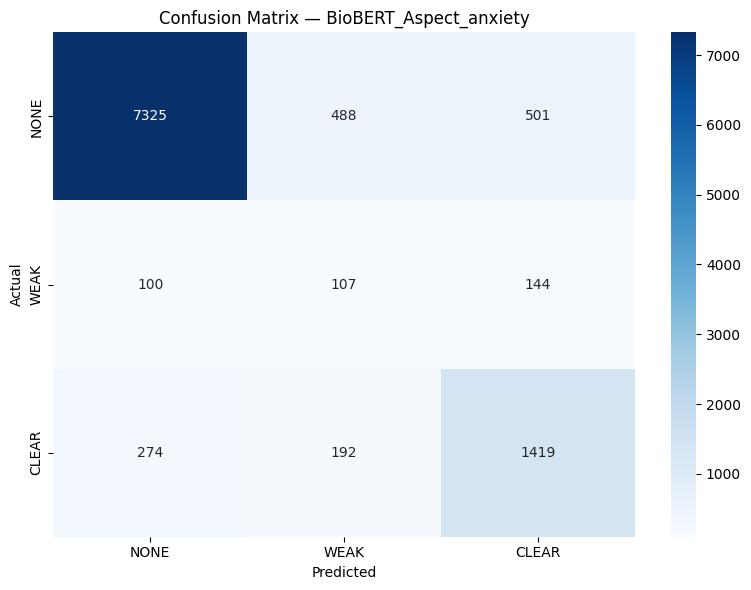


BioBERT — SUICIDAL (3-class: NONE/WEAK/CLEAR)
              precision    recall  f1-score   support

        NONE     0.9660    0.8575    0.9085      7887
        WEAK     0.1015    0.3284    0.1551       201
       CLEAR     0.7399    0.8712    0.8002      2462

    accuracy                         0.8506     10550
   macro avg     0.6025    0.6857    0.6213     10550
weighted avg     0.8968    0.8506    0.8689     10550

Weighted F1: 0.8689  95% CI [0.8632, 0.8745]
Saved → ./06_AspectLabel/outputs/BioBERT_Aspect_suicidal_confusion_matrix.png


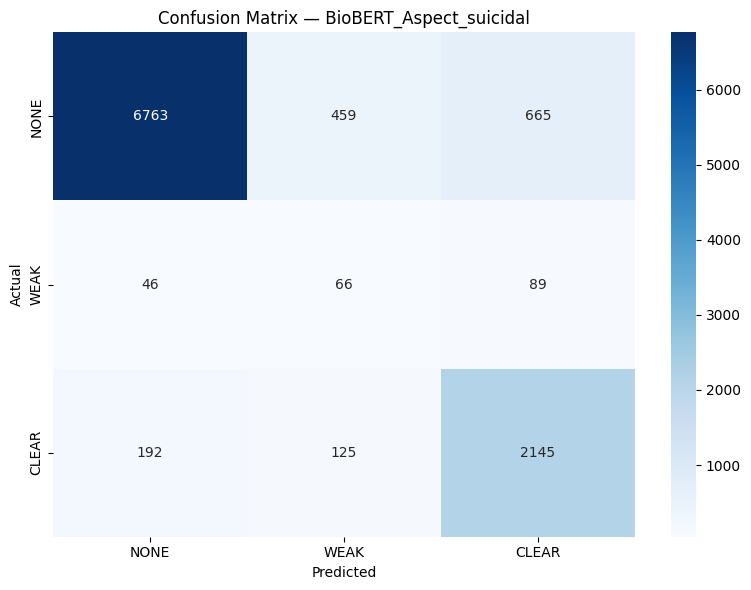


BioBERT — STRESS (3-class: NONE/WEAK/CLEAR)
              precision    recall  f1-score   support

        NONE     0.9223    0.7072    0.8006      8531
        WEAK     0.2241    0.5071    0.3108      1189
       CLEAR     0.3794    0.6024    0.4655       830

    accuracy                         0.6764     10550
   macro avg     0.5086    0.6056    0.5256     10550
weighted avg     0.8009    0.6764    0.7190     10550

Weighted F1: 0.7192  95% CI [0.7119, 0.7270]
Saved → ./06_AspectLabel/outputs/BioBERT_Aspect_stress_confusion_matrix.png


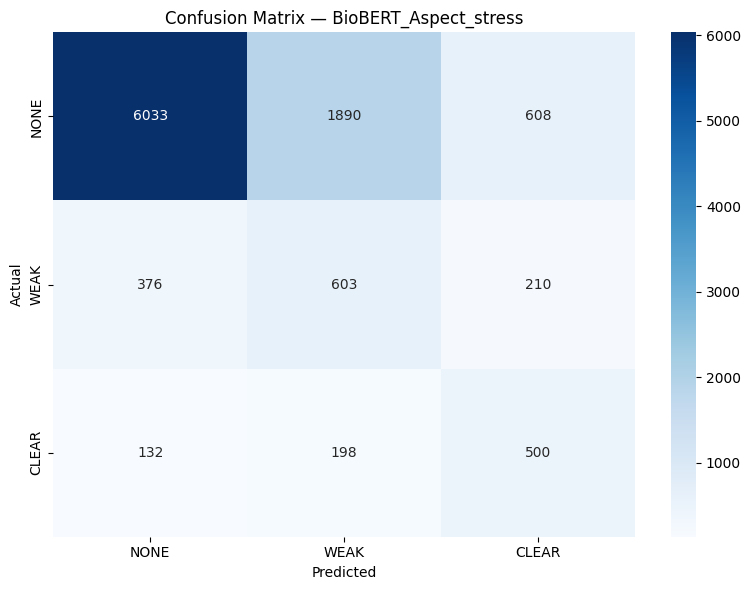


BioBERT — BIPOLAR (3-class: NONE/WEAK/CLEAR)
              precision    recall  f1-score   support

        NONE     0.9958    0.9845    0.9901     10196
        WEAK     0.1667    0.2875    0.2110        80
       CLEAR     0.6867    0.8321    0.7525       274

    accuracy                         0.9753     10550
   macro avg     0.6164    0.7014    0.6512     10550
weighted avg     0.9815    0.9753    0.9781     10550

Weighted F1: 0.9782  95% CI [0.9754, 0.9807]
Saved → ./06_AspectLabel/outputs/BioBERT_Aspect_bipolar_confusion_matrix.png


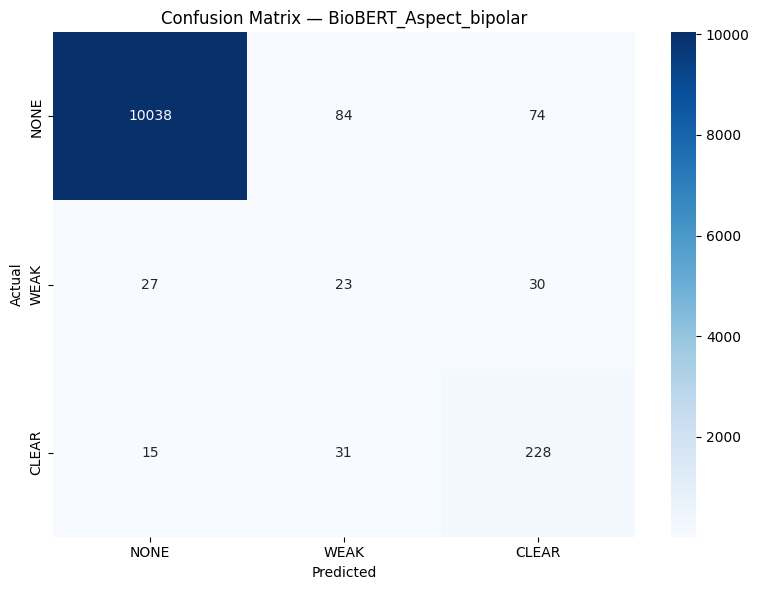


BioBERT — PERSONALITY_DISORDER (3-class: NONE/WEAK/CLEAR)
              precision    recall  f1-score   support

        NONE     0.9877    0.9682    0.9778     10276
        WEAK     0.1201    0.2179    0.1549       156
       CLEAR     0.2990    0.4915    0.3718       118

    accuracy                         0.9518     10550
   macro avg     0.4689    0.5592    0.5015     10550
weighted avg     0.9672    0.9518    0.9589     10550

Weighted F1: 0.9589  95% CI [0.9553, 0.9624]
Saved → ./06_AspectLabel/outputs/BioBERT_Aspect_personality_disorder_confusion_matrix.png


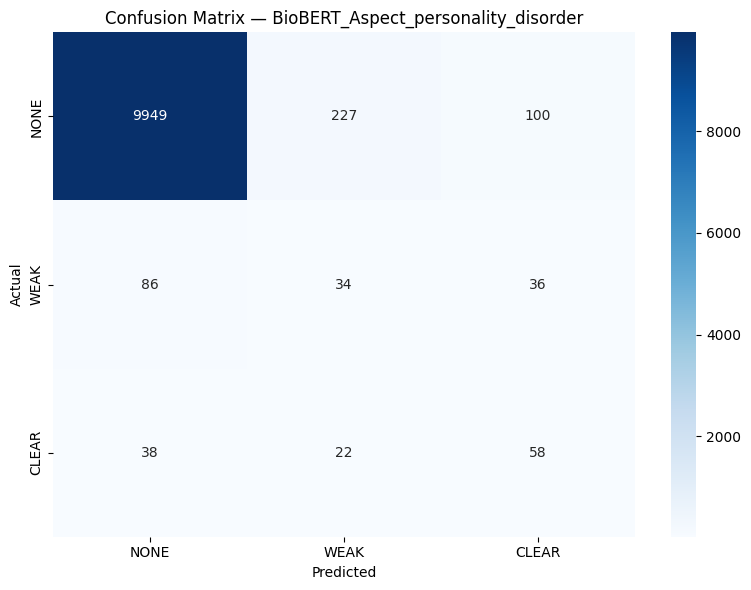

In [24]:
biobert_results = evaluate_aspects(
    best_biobert, test_loader_biobert, "BioBERT", save_dir=str(OUTPUT_PATH)
)

## 3.6 Save Prediction

In [25]:
df_test_out = df_test[[TEXT_COLUMN]].copy()

# Aspect predictions
for asp in ASPECT_NAMES:
    short = asp_display(asp)
    df_test_out[f"albert_{short}_pred"] = albert_results[asp]["y_pred"]
    df_test_out[f"biobert_{short}_pred"] = biobert_results[asp]["y_pred"]
    df_test_out[f"{short}_true"] = albert_results[asp]["y_true"]

pred_path = OUTPUT_PATH / "test_predictions_aspect.csv"
df_test_out.to_csv(pred_path, index=False)
print(f"\nSaved predictions → {pred_path}")

# ── Summary ──────────────────────────────────────────────
print("\n" + "=" * 60)
print("SUMMARY — Aspect-Only 3-Class (Mental Health)")
print("=" * 60)
for model_name, results in [("ALBERT", albert_results), ("BioBERT", biobert_results)]:
    print(f"\n{model_name}:")
    f1s = []
    for asp in ASPECT_NAMES:
        r = results[asp]
        short = asp_display(asp)
        print(f"  {short:25s} F1: {r['f1_weighted']:.4f} "
              f"[{r['f1_ci'][0]:.4f}, {r['f1_ci'][1]:.4f}]")
        f1s.append(r['f1_weighted'])
    print(f"  {'MEAN':25s} F1: {np.mean(f1s):.4f}")


Saved predictions → ./06_AspectLabel/outputs/test_predictions_aspect.csv

SUMMARY — Aspect-Only 3-Class (Mental Health)

ALBERT:
  depression                F1: 0.7997 [0.7923, 0.8070]
  anxiety                   F1: 0.8445 [0.8381, 0.8516]
  suicidal                  F1: 0.8729 [0.8671, 0.8794]
  stress                    F1: 0.7070 [0.6995, 0.7147]
  bipolar                   F1: 0.9728 [0.9698, 0.9756]
  personality_disorder      F1: 0.9575 [0.9539, 0.9611]
  MEAN                      F1: 0.8591

BioBERT:
  depression                F1: 0.7955 [0.7885, 0.8025]
  anxiety                   F1: 0.8556 [0.8494, 0.8619]
  suicidal                  F1: 0.8689 [0.8632, 0.8745]
  stress                    F1: 0.7192 [0.7119, 0.7270]
  bipolar                   F1: 0.9782 [0.9754, 0.9807]
  personality_disorder      F1: 0.9589 [0.9553, 0.9624]
  MEAN                      F1: 0.8627
